In [12]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *

print("Fixed Income Library is loaded.")

Added to sys.path:/ c:\Users\neels\OneDrive\Desktop\Study_Materials\Classes\Design Pattern - Jay's Course\FRE-GT-9743-Assignment-8\FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [13]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

In [14]:
### hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': np.float64(0.30753370804464425),
 'd_ln_sigma_d_alpha': np.float64(2.7836494264635085),
 'd_ln_sigma_d_beta': np.float64(-0.7671990084031498),
 'd_ln_sigma_d_rho': np.float64(0.004799436158126009),
 'd_ln_sigma_d_nu': np.float64(0.017789228437936358),
 'd_ln_sigma_d_forward': np.float64(-2.3980198155654064),
 'd_ln_sigma_d_strike': np.float64(0.8458659814736144),
 'd_ln_sigma_d_tte': np.float64(0.007562343085309908),
 'd_ln_sigma_d_strike_strike': np.float64(14.983951453894674)}

In [15]:
derivative_keys = [
    SabrMetrics.D_LN_SIGMA_D_FORWARD,
    SabrMetrics.D_LN_SIGMA_D_STRIKE,
    SabrMetrics.D_LN_SIGMA_D_TTE,
    SabrMetrics.D_LN_SIGMA_D_ALPHA,
    SabrMetrics.D_LN_SIGMA_D_BETA,
    SabrMetrics.D_LN_SIGMA_D_RHO,
    SabrMetrics.D_LN_SIGMA_D_NU,
]

In [16]:
### b&r test
key = SimpleMetrics.IMPLIED_LOG_NORMAL_VOL
base_v = res_imp_log_normal_vol[key]

epsilon = 1e-6
bump_vec = [0.0] * 7
for i in range(len(bump_vec)):
    bump_vec[i] += epsilon
    bumped_v = qfEuropeanOptionSABRLogNormalSigma(
        forward + bump_vec[0],
        strike + bump_vec[1],
        tte + bump_vec[2],
        alpha + bump_vec[3],
        beta + bump_vec[4],
        rho + bump_vec[5],
        nu + bump_vec[6],
        shift,
        False,
    )
    analytical_derivative = res_imp_log_normal_vol[derivative_keys[i]]
    numerical_derivative = (bumped_v[key] - base_v) / epsilon
    print(
        f"Param {i} - Numerical: {numerical_derivative:.10f}, Analytical: {analytical_derivative:.10f}, Diff: {numerical_derivative - analytical_derivative:.2e}"
    )
    bump_vec[i] -= epsilon

Param 0 - Numerical: -2.3979917391, Analytical: -2.3980198156, Diff: 2.81e-05
Param 1 - Numerical: 0.8458734767, Analytical: 0.8458659815, Diff: 7.50e-06
Param 2 - Numerical: 0.0075623431, Analytical: 0.0075623431, Diff: 5.53e-11
Param 3 - Numerical: 2.7836495945, Analytical: 2.7836494265, Diff: 1.68e-07
Param 4 - Numerical: -0.7671980359, Analytical: -0.7671990084, Diff: 9.73e-07
Param 5 - Numerical: 0.0047994295, Analytical: 0.0047994362, Diff: -6.64e-09
Param 6 - Numerical: 0.0177892389, Analytical: 0.0177892284, Diff: 1.04e-08


# 2. Detection of Negative Density

The parameters set is:

In [17]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

In [18]:
# Without implementing the algorithm it is clear that the time to expiry is the main culprit in causing the arbitrage on the left wing 
# since Hagan's vol of vol expansion requires a short time to maturity to be accurate. 
def left_wing_arbitrage_score(
    forward,
    tte,
    alpha,
    beta,
    rho,
    nu,
    x_min,
    x_max,
    num_pts,
    shift=0.0,
    eps=1e-8,
):
    df_res = qfEuropeanOptionSABRPdfAndCdf(
        forward,
        tte,
        alpha,
        beta,
        rho,
        nu,
        x_min,
        x_max,
        num_pts,
        shift,
        True,
        False,
    )
    pdf = df_res["Pdf"].values

    min_pdf = float(np.min(pdf))
    has_arb = np.any(pdf < -eps)

    first_idx = np.where(pdf[::-1] < -eps)[0]
    first_x = None if len(first_idx) == 0 else float(df_res.iloc[first_idx[0]]["Forward"])

    return {
        "has_arbitrage": has_arb,
        "min_pdf": min_pdf,
        "first_arbitrageable_strike": first_x,
        "df": df_res,
    }

# Keep other params the same while changing only 1 parameter
def scan_one_parameter(
    param_name,
    values,
    forward,
    tte,
    alpha,
    beta,
    rho,
    nu,
    x_min,
    x_max,
    num_pts,
    shift=0.0,
    eps=1e-8,
):
    results = []

    for value in values:
        a = alpha
        b = beta
        r = rho
        n = nu
        T = tte

        if param_name == "alpha":
            a = value
        elif param_name == "beta":
            b = value
        elif param_name == "rho":
            r = value
        elif param_name == "nu":
            n = value
        elif param_name == "tte":
            T = value
        else:
            raise ValueError(f"Unknown parameter: {param_name}")

        out = left_wing_arbitrage_score(
            forward=forward,
            tte=T,
            alpha=a,
            beta=b,
            rho=r,
            nu=n,
            x_min=x_min,
            x_max=x_max,
            num_pts=num_pts,
            shift=shift,
            eps=eps,
        )

        results.append({
            "parameter": param_name,
            "value": value,
            "has_arbitrage": out["has_arbitrage"],
            "min_pdf": out["min_pdf"],
            "first_arbitrageable_strike": out["first_arbitrageable_strike"],
        })

    return pd.DataFrame(results)

In [19]:
alpha_values = [0.01, 0.0512, 0.1]
beta_values  = [0.0, 0.5, 1.0]
rho_values   = [-0.99, -0.5, 0.0, 0.5, 0.99]
nu_values    = np.linspace(0.05, 2.0, 10)
tte_values   = [1.0, 2.0, 5.0, 10.0]
x_min, x_max = - shift + 1e-4, 0.1
num_pts = 1000

df_alpha = scan_one_parameter(
    "alpha", alpha_values, forward, tte, alpha, beta, rho, nu, x_min, x_max, num_pts, shift
)

df_beta = scan_one_parameter(
    "beta", beta_values, forward, tte, alpha, beta, rho, nu, x_min, x_max, num_pts, shift
)

df_rho = scan_one_parameter(
    "rho", rho_values, forward, tte, alpha, beta, rho, nu, x_min, x_max, num_pts, shift
)

df_nu = scan_one_parameter(
    "nu", nu_values, forward, tte, alpha, beta, rho, nu, x_min, x_max, num_pts, shift
)

df_tte = scan_one_parameter(
    "tte", tte_values, forward, tte, alpha, beta, rho, nu, x_min, x_max, num_pts, shift
)
df_all = pd.concat([df_alpha, df_beta, df_rho, df_nu, df_tte], ignore_index=True)
df_all

,parameter,value,has_arbitrage,min_pdf,first_arbitrageable_strike
0,alpha,0.010000,False,0.033025,NaN
1,alpha,0.051200,True,-1222.007143,0.001734
2,alpha,0.100000,True,-186.391530,0.000773
3,beta,0.000000,True,-3.200257,0.000100
4,beta,0.500000,True,-1222.007143,0.001734
5,beta,1.000000,False,0.035667,NaN
6,rho,-0.990000,True,-11.538868,0.001758
7,rho,-0.500000,True,-589.865619,0.001419
8,rho,0.000000,True,-1336.006320,0.001871
9,rho,0.500000,True,-1516.703318,0.003581


# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

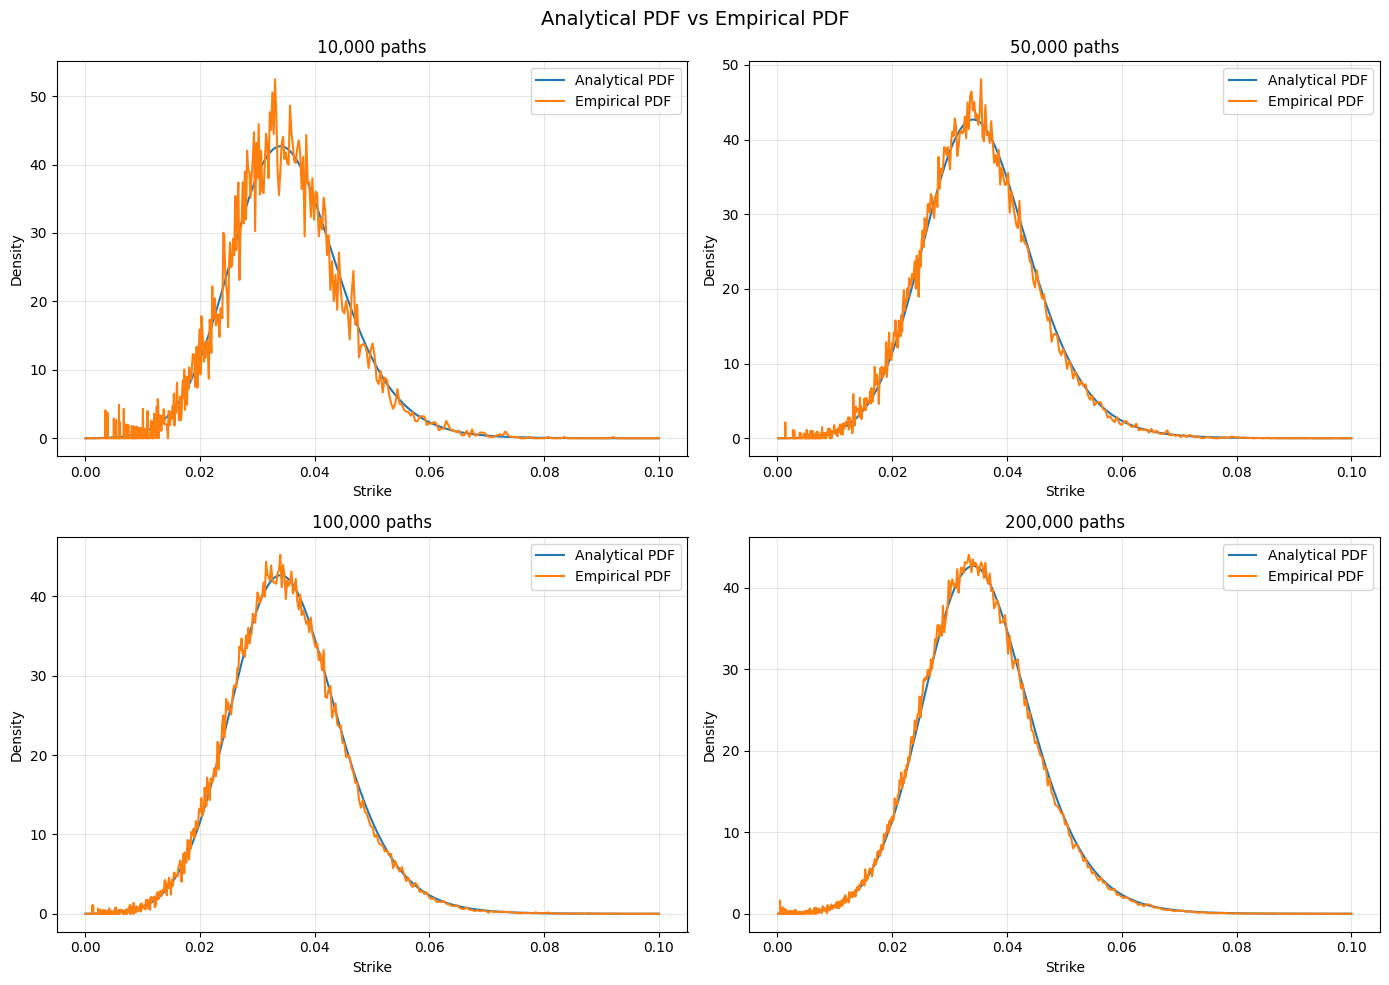

In [20]:
import matplotlib.pyplot as plt

### Choose a set of parameters without static arbitrage on left wing. For simplicity our function to simulate the paths does not consider shifts.
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 1

# grid spec
x_min = -shift + 1e-4
x_max = 0.1
num_pts = 1000

# Analytical formula for CDF and PDF
df_res = qfEuropeanOptionSABRPdfAndCdf(
    forward,
    tte,
    alpha,
    beta,
    rho,
    nu,
    x_min,
    x_max,
    num_pts,
    shift,
    True,
    False,
)
grids = df_res['Forward'].values
analytical_pdf = df_res['Pdf'].values


# Analytical vs Empirical PDFs for different number of paths
num_paths = [10000, 50000, 100000, 200000]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, num_path in zip(axes, num_paths):
    edges, simulated_pdf = SABRAnalytics.simulate_pdf(
        forward,
        tte,
        alpha,
        beta,
        rho,
        nu,
        grids,
        num_paths=num_path,   
    )

    ax.plot(grids, analytical_pdf, label="Analytical PDF")
    ax.plot(grids, simulated_pdf, label="Empirical PDF")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Density")
    ax.set_title(f"{num_path:,} paths")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("Analytical PDF vs Empirical PDF", fontsize=14)
fig.tight_layout()
plt.show()

# 4. Quantile Map


In [21]:
from scipy.interpolate import PchipInterpolator
from scipy.stats import norm, qmc

# Helper functions to construct our interpolator and correlated y_i's
def construct_interpolator(
    forward : float, 
    time_to_expiry: float, 
    sigma_atm_normal: float,
    beta: float, 
    rho: float,
    nu: float,
    grids: List | np.ndarray,
    shift: Optional[float] = 0,
) : 
    # Get alpha from atm_normal_sigma first
    res = SABRAnalytics.alpha_from_atm_normal_sigma(
        forward,
        time_to_expiry,
        sigma_atm_normal,
        beta,
        rho,
        nu,
        shift
    )
    alpha = res[SabrMetrics.ALPHA]
    _, _, cdfs, pdfs = SABRAnalytics.pdf_and_cdf(
        forward,
        time_to_expiry,
        alpha,
        beta,
        rho,
        nu,
        grids,
        shift
    )

    # Convert to arr, then take the CDF at the x_i's and then take the inverse norm CDF function which is norm.ppf
    cdf_arr = np.asarray(cdfs, dtype = float) 
    y_arr = norm.ppf(cdf_arr)

    # We use the PchipInterpolator which is 1D interpolation that creates a smooth, continuous curve while preserving monotonocity
    return PchipInterpolator(y_arr, grids, extrapolate=True)

def generate_sobol_normals(
    dim: int,                  # This is the dimension of our samples from a low discrepancy sequence of Sobol
    corr: np.ndarray, 
    m : int = 20,              # To be precise we will generate 2^m samples (as per scipy params)
    scramble: bool = True,     # Params of scipy Sobol class
    seed : int | None = 42,    # Random seed for reproducing results
    tol: float = 1e-8 
):
    """
    Generate correlated standard normals using Sobol + inverse normal + Cholesky.
    """

    # First check if correlation matrix is symmetric
    if not np.allclose(corr, corr.T):
        raise ValueError("Correlation matrix must be symmetric!")

    # Then check if correlation matrix is positive semi definite by checking for non-negative eigenvalues
    eigenvalues = np.linalg.eigvalsh(corr)
    if np.any(eigenvalues <= 0):
        raise ValueError("Correlation matrix must be positive definite for Cholesky!")

    num_samples = 2 ** m 
    sampler = qmc.Sobol(d = dim, scramble = scramble, seed = seed)
    samples = sampler.random_base2(m = m) # Generates 2^m samples which are uniformly distributed

    # Clip sampled u_i's that are 0 or 1 to be slightly above 0 or slightly below 1 for better interpolation
    # since our CDF range will never reach 0 or 1 
    samples = np.clip(samples, 1e-4, 1 - 1e-4)
    y_ind = norm.ppf(samples)

    # Cholesky Decomposition of correlation matrix 
    L = np.linalg.cholesky(corr)
    y_corr = y_ind @ L.T
    return y_corr

# ----------- Main Function to price our spread option ------------
def spread_option_quantile_map(
    params1: List | np.ndarray,  
    params2: List | np.ndarray,
    rho12 : float,
    K : float,
    s1_grids: List | np.ndarray,
    s2_grids: List | np.ndarray,
    m : int = 20,                 # To be precise we will generate 2^m samples (as per scipy params)
    shift: Optional[float] = 0,
    scramble: bool = True,
    seed: int | None = 42,
): 
    # The order of the params should be forward, tte, sigma_n, beta, rho, nu 
    F1, tte1, sigma1_n, beta1, rho1, nu1 = params1[0], params1[1], params1[2], params1[3], params1[4], params1[5]
    F2, tte2, sigma2_n, beta2, rho2, nu2 = params2[0], params2[1], params2[2], params2[3], params2[4], params2[5]
    
    # Build interpolators for both S1 and S2
    I1 = construct_interpolator(
        forward = F1,
        time_to_expiry = tte1,
        sigma_atm_normal = sigma1_n,
        beta = beta1,  
        rho = rho1,
        nu = nu1,
        grids = s1_grids,
        shift = shift
    ) 
        
    I2 = construct_interpolator(
        forward = F2,
        time_to_expiry = tte2,
        sigma_atm_normal = sigma2_n,
        beta = beta2,  
        rho = rho2,
        nu = nu2,
        grids = s2_grids,
        shift = shift
    ) 

    # Generate normals with given correlation matrix
    corr = np.array([[1.0, rho12], [rho12, 1.0]], dtype=float)
    y = generate_sobol_normals(
        dim = 2,
        corr = corr,
        m = m,
        scramble = scramble,
        seed = seed,
    )
    
    # Apply marginal quantile maps component-wise
    s1 = I1(y[:, 0])
    s2 = I2(y[:, 1])

    payoff = np.maximum(s1 - s2 - K, 0.0)
    return float(np.mean(payoff))

In [22]:
# We assume no shift for simplicity. Initialise our params here
s1_params = [0.03, 1, 0.01, 0.5, 0.25, 0.2]
s2_params = [0.05, 1, 0.012, 0.5, 0.45, 0.15]
rho12 = 0.9 # Correlation between S1 and S2
K = 0.001
NUM_POINTS = 1000 

# For the grid generation, we set the min grid at 0 + eps, and the max grid to be the forward + 6 * atm_sigma_normal * sqrt(T)
s1_grid_min, s1_grid_max = 1e-4, s1_params[0] + 6 * s1_params[2] * np.sqrt(s1_params[1]) 
ln_s1_grid_min, ln_s1_grid_max = np.log(s1_grid_min), np.log(s1_grid_max)
spacing = (ln_s1_grid_max - ln_s1_grid_min) / (NUM_POINTS - 1)
ln_s1_grids = np.arange(ln_s1_grid_min, ln_s1_grid_max + spacing / 2, spacing)
s1_grids = np.exp(ln_s1_grids)

s2_grid_min, s2_grid_max = 1e-4, s2_params[0] + 6 * s2_params[2] * np.sqrt(s2_params[1]) 
ln_s2_grid_min, ln_s2_grid_max = np.log(s2_grid_min), np.log(s2_grid_max)
spacing = (ln_s2_grid_max - ln_s2_grid_min) / (NUM_POINTS - 1)
ln_s2_grids = np.arange(ln_s2_grid_min, ln_s2_grid_max + spacing / 2, spacing)
s2_grids = np.exp(ln_s2_grids)

# Finally we can generate our price
spread_option_price = spread_option_quantile_map( 
    s1_params,  
    s2_params,
    rho12, 
    0.001,
    s1_grids,
    s2_grids
)

print(f"Spread Option price using Quantile Mapping is: {spread_option_price:.2e}")

Spread Option price using Quantile Mapping is: 6.87e-08


#### Bonus: how can we validate our answer?

The first thing to note is that the high positive correlation means that S1 and S2 move in similar directions and thus it is not surprising that the spread option price will be relatively small.

Simulating the paths of S1 and S2 directly is possible, although it is hard to simulate it directly given that S1 and S2 are positively correlated with a correlation coefficient of 0.9

1 way that might be effective and efficient is to use a SABR model to model the dynamics of the spread (S1-S2) using a SABR model and perform moment matching where we can match up to the fourth moments given that we have 4 parameters. The drawback of this is that risk generation may be complex, but it works fine if we are simply interested in pricing the spread option for validation.

# 5. Struggling With Correlation

1. Suppose we are given an empirical correlation matrix for three term rates:

   $$
   C =
   \begin{bmatrix}
   1 & 0.9 & 0.9 \\
   0.9 & 1 & -0.9 \\
   0.9 & -0.9 & 1
   \end{bmatrix}
   \tag{1}
   $$

   Show it is not positive semi-definite. Intuitively, do you see any issues from the correlation matrix $C$?


#### Proof for Q5(i) 

We can compute the determinant of the matrix C. A quick computation of det(C) gives us 
\begin{equation}
    det(C) = (1 - 0.9^2) - 0.9 \times (0.9 + 0.9^2) + 0.9 \times (-0.9^2 - 0.9) < 0 
\end{equation}
Since the determinant is not non-negative then the matrix is indeed not positive semi-definite. 

Intuitively, let us denote the term factors as $R_1, R_2 \text{ and } R_3$. If C is truly a correlation matrix, then we have $corr(R_1,R_2) = 0.9$ and $corr(R_1,R_3) = 0.9$, but $corr(R_2,R_3) = -0.9$. This is counter-inutitive since if $R_2$ increases, then $R_1$ should increase similarly, and because $corr(R_1,R_3) = 0.9$ then we would expect $R_3$ to increase similarly. This implies that we would expect a rather strong positive correlation between $R_2$ and $R_3$ contrary to what our matrix $C$ implies. 

This can present some problems during the simulation process when we want to perform a Cholesky/SVD decomposition of our correlation matrix which requires our matrix to be positive semi-definite. If it is not then we cannot perform our decomposition to obtain the empiral correlation matrix for simulation.

2. Given the following generator of a correlation matrix:

$$
\rho(i,j;\eta,\lambda)
=
\eta + (1-\eta)\exp\{-\lambda |T_i - T_j|\},
\qquad \forall i,j
\tag{2}
$$

where $T_i$ and $T_j$ stands for the term, and $\eta, \lambda \ge 0$. Prove $[\rho_{ij}]$ is positive semi-definite matrix.

*Hint:*

- it suffices to prove for any $a_i, a_j$,
  $$
  \sum a_i a_j \rho_{ij} \ge 0
  $$

- 
  $$
  e^{-\lambda |x|}
  =
  \frac{2\lambda}{|\pi|}
  \int_0^\infty \frac{\cos(wx)}{\lambda^2 + w^2}\,dw,
  \qquad \text{for } \lambda > 0.
  $$

#### Proof for Q5(ii) 
As per the hint and using the trigonometric identity $cos(A-B) = cos(A)cos(B) + sin(A)sin(B)$, we have
\begin{align}
\sum a_i a_j \rho_{ij}
&= \sum a_i a_j \left( \eta + (1-\eta)\exp\{-\lambda |T_i - T_j|\} \right) \\
&= \sum a_i a_j \eta +  \frac{2\lambda ( 1 - \eta)}{|\pi|} \int_0^\infty \frac{\sum a_i a_j \cos(w(T_i - T_j))}{\lambda^2 + w^2}\,dw \qquad \text{ (Assume Fubini's Theorem holds)} \\
&= \sum a_i a_j \eta +  \frac{2\lambda ( 1 - \eta)}{|\pi|} \int_0^\infty \frac{\sum a_i a_j (\cos(wT_i)\cos(wT_j) + \sin(wT_i)\sin(wT_j))}{\lambda^2 + w^2}\,dw 
\end{align}

We then observe the following identities
\begin{equation}
    \sum a_i a_j \eta = \left( \sum_i a_i \sqrt{\eta} \right)^2 \geq 0, \quad \sum a_i a_j (\cos(wT_i)\cos(wT_j) + \sin(wT_i)\sin(wT_j)) = \left( \sum_i a_i \cos(wT_i) \right)^2 + \left( \sum_i a_i \sin(wT_i) \right)^2 \geq 0
\end{equation}
and the result immediately follows since $ \frac{2\lambda ( 1 - \eta)}{|\pi|(\lambda^2 + w^2)} \geq 0 $

3. Find the "closest" positive semi-definite matrix to \(C\).

*Hint:*

- use python `np.linalg.norm` and `scipy.minimize`.

- optimize with Frobenius norm
  $$
  \lVert \rho - C \rVert^2.
  $$

In [23]:
from scipy.optimize import minimize

def correlation_generator(
    terms: List | np.ndarray, 
    eta: float, 
    lam: float
):
    """
    Generate rho_ij = eta + (1-eta) exp(-lam |T_i - T_j|).
    """
    terms = np.asarray(terms, dtype=float)
    dist = np.abs(terms[:, None] - terms[None, :])
    rho = eta + (1.0 - eta) * np.exp(-lam * dist)
    return rho


def closest_positive_semidefinite_matrix(
    C: np.ndarray,
    terms: List | np.ndarray,
):
    # Check if C is a square matrix 
    if C.ndim != 2 or C.shape[0] != C.shape[1]:
        raise ValueError("C must be a square matrix")
    if len(terms) != C.shape[0]:
        raise ValueError("terms must have the same length as C dimension")\

    # Define our objective function 
    def objective(params:  List | np.ndarray):
        eta, lam = params[0], params[1]
        rho = correlation_generator(terms, eta, lam) 
        return np.linalg.norm(rho - C, ord="fro")**2

    # Bounds for eta and lambda + initial guess
    initial_guess = [2,0.5]
    bounds = [(0.0, None), (0.0, None)]
    res = minimize( 
        objective,
        x0 = initial_guess,
        bounds=bounds,
        method="L-BFGS-B",
    )

    opt_rho =  correlation_generator(terms, res.x[0], res.x[1]) 
    return opt_rho

# ------------------ Main code to compute "closest" positive semi-definite matrix to C ------------------
C = np.array([[1.0, 0.9, 0.9],
             [0.9, 1.0, -0.9],
             [0.9, -0.9, 1.0]])
terms = [1, 1.1,1.4] # Not given in the question so I shall just assume some term values. 

opt_rho = closest_positive_semidefinite_matrix(C, terms) 
opt_rho

array([[1.        , 0.51214715, 0.11192117],
       [0.51214715, 1.        , 0.1657963 ],
       [0.11192117, 0.1657963 , 1.        ]])